Import the Dataset

In [774]:
import pandas as pd
df = pd.read_csv("Titanic-Dataset.csv")

In [775]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Data Exploration

In [776]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [777]:
df.info() # all about Dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Data cleaning

Removeing all the Null values

In [778]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [779]:
df = df.drop("Cabin", axis = 1 )

In [780]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [781]:
df['Age'].skew() # Check the Skewness when skew > 0.50 then use median() and skew < 0.50 then mean()

np.float64(0.38910778230082704)

In [782]:
df['Age'] = df['Age'].fillna(df['Age'].mean()) # Filling the Null values 

In [783]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [784]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [785]:
df.isnull().sum() # check the Null Values

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Removing All duplicates

In [786]:
print(df.duplicated().sum())

0


<Axes: >

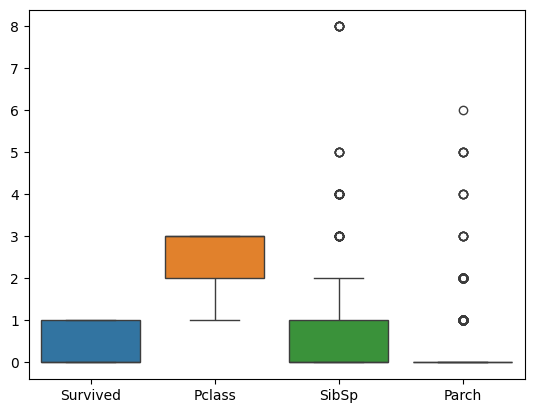

In [787]:
import seaborn as sns
sns.boxplot([df['Survived'],df['Pclass'], df['SibSp'],df['Parch']]) # Show the Outliers in your columns

In [788]:
# df['Name'].replace(r'[^A-Za-z]' , ' ', regex = True)
# df['Name'].replace(',' , '', regex = True).replace(" ", "")



### How to Know where is store this folder? 

In [789]:
import os
print(os.getcwd())

c:\Users\Arun Kumar\EDA_Project_IEP


### Selected Only Numercial column

In [790]:
df['Age'] = df['Age'].astype(int)
df['Fare'] = df['Fare'].astype(int)

In [791]:
import numpy as np
a = df.select_dtypes(include=np.number)

In [792]:
a

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22,1,0,7
1,2,1,1,38,1,0,71
2,3,1,3,26,0,0,7
3,4,1,1,35,1,0,53
4,5,0,3,35,0,0,8
...,...,...,...,...,...,...,...
886,887,0,2,27,0,0,13
887,888,1,1,19,0,0,30
888,889,0,3,29,1,2,23
889,890,1,1,26,0,0,30


## Find Outliers

In [793]:
for i in a:
    q1 = a[i].quantile(0.25)
    q2 = a[i].quantile(0.50)
    q3 = a[i].quantile(0.75)

    IQR = q3 - q1
    upper = q3 + 1.5 * IQR
    lower = q1 -  1.5 * IQR 
    outliers1 = (a[i] > upper) | (a[i] < lower)
    print(outliers1.value_counts())

PassengerId
False    891
Name: count, dtype: int64
Survived
False    891
Name: count, dtype: int64
Pclass
False    891
Name: count, dtype: int64
Age
False    825
True      66
Name: count, dtype: int64
SibSp
False    845
True      46
Name: count, dtype: int64
Parch
False    678
True     213
Name: count, dtype: int64
Fare
False    777
True     114
Name: count, dtype: int64


In [794]:
for i in a:

    q1 = a[i].quantile(0.25)
    q2 = a[i].quantile(0.50)
    q3 = a[i].quantile(0.75)

    IQR = q3 - q1
    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR
    
    outliers = a.loc[(a[i] > upper) | (a[i] < lower), i]

    a.loc[a[i] > upper , i ] = upper
    a.loc[a[i] < lower, i] = lower

    print(i, ":", outliers.count())

PassengerId : 0
Survived : 0
Pclass : 0
Age : 66
SibSp : 46
Parch : 213
Fare : 114


C:\Users\Arun Kumar\AppData\Local\Temp\ipykernel_16712\1208862461.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  a.loc[a[i] > upper , i ] = upper
C:\Users\Arun Kumar\AppData\Local\Temp\ipykernel_16712\1208862461.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  a.loc[a[i] > upper , i ] = upper
C:\Users\Arun Kumar\AppData\Local\Temp\ipykernel_16712\1208862461.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '54.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  a.loc[a[i] > upper , i ] = upper
C:\Users\Aru

In [795]:
for i in a.select_dtypes(include='number').columns:

    q1 = a[i].quantile(0.25)
    q3 = a[i].quantile(0.75)
    q2 = a[i].median()

    IQR = q3 - q1

    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR

    outliers2 = a.loc[(a[i] > upper) | (a[i] < lower), i]

    a.loc[(a[i] > upper) | (a[i] < lower), i] = q2

    print(i, "Outliers:", outliers2.count())

PassengerId Outliers: 0
Survived Outliers: 0
Pclass Outliers: 0
Age Outliers: 0
SibSp Outliers: 0
Parch Outliers: 0
Fare Outliers: 0


In [796]:
df['PassengerId'].count() #  How many passenger in the Dataset 

np.int64(891)

#### Survived (1)  Means live  
#### Un Survived (0) Means died  

In [797]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

### Most of the people  died in the incident.

In [798]:
aa = df.groupby("Sex")["Survived"].mean()*100
aa

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

###  Most females survived in the incident.

*Binning*

In [799]:
bins = [0,18,40,80]
labels = ['Child', "Adult","Old"]
df['AgeGroup'] = pd.cut(df['Age'],bins = bins , labels = labels )

In [800]:
b = df.groupby('AgeGroup')['Survived'].mean()* 100
b

C:\Users\Arun Kumar\AppData\Local\Temp\ipykernel_16712\2786697629.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  b = df.groupby('AgeGroup')['Survived'].mean()* 100


AgeGroup
Child    47.727273
Adult    35.927152
Old      37.162162
Name: Survived, dtype: float64

### Most of the Child survived in the incident comapre to adult or old person

In [801]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7,S,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71,C,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7,S,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53,S,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8,S,Adult


In [802]:
c = df.groupby("Pclass")["Survived"].mean()*100
c

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

In [803]:
df.sort_values(by="Fare", ascending = False).head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup
737,738,1,1,"Lesurer, Mr. Gustave J",male,35,0,0,PC 17755,512,C,Adult
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36,0,1,PC 17755,512,C,Adult
258,259,1,1,"Ward, Miss. Anna",female,35,0,0,PC 17755,512,C,Adult
438,439,0,1,"Fortune, Mr. Mark",male,64,1,4,19950,263,S,Old
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24,3,2,19950,263,S,Adult


### The people who are paying the more are survived the mode

# Data Visualiztion

In [804]:
import matplotlib.pyplot as plt
import seaborn as sns

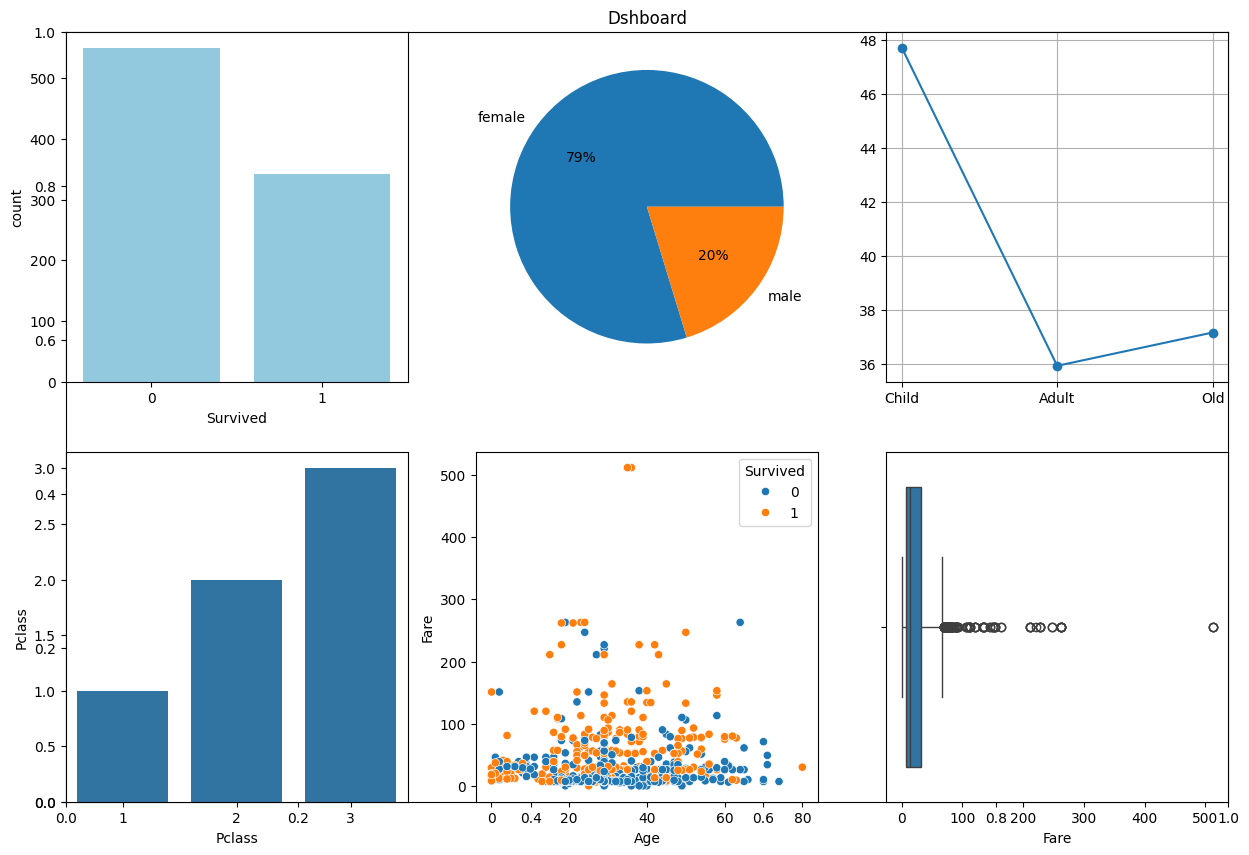

In [ ]:
plt.figure(figsize=(15,10))
plt.title("Dshboard")

plt.subplot(2,3,1)
sns.countplot(x="Survived", data = df, color = "skyblue")

plt.subplot(2,3,2)
plt.pie(aa.values, labels = aa.index, autopct = "%1.d%%")

plt.subplot(2,3,3)
plt.plot(b.index, b.values, marker= "o")
plt.grid(True)

plt.subplot(2,3,4)
sns.barplot(x= c.index, y= c.index,)

plt.subplot(2,3,5)
sns.scatterplot(x="Age", y="Fare", hue='Survived',data = df )    
plt.subplot(2,3,6)
sns.boxplot(x='Fare', data = df)

plt.show()

# Data Story Telling

### 1. Most of the people died in the incident.
### 2. Most of the female survived  in the incident.
### 3. Most of the child  survived  in the incident.
### 4. Passenger from class 1 survived  the most.
### 5. People who are paying more are surviving the more.
### 6. Around 20 people are paying more than average Fare.
